<a href="https://colab.research.google.com/github/Moussadiey/DIEYE/blob/main/RANDOM%20FOREST%20MODEL%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MACHINE LEARNING PAR LIDAR HD ET GREEHILL FORET ALEATOIRE

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option SEP
  return ogr_read(


Index(['ID_GEOFLA', 'CODE_COM', 'INSEE_COM', 'NOM_COM', 'STATUT', 'X_CHF_LIEU',
       'Y_CHF_LIEU', 'X_CENTROID', 'Y_CENTROID', 'Z_MOYEN', 'SUPERFICIE',
       'POPULATION', 'CODE_ARR', 'CODE_DEPT', 'NOM_DEPT', 'CODE_REG',
       'NOM_REG', 'layer', 'path', 'geometry'],
      dtype='object')


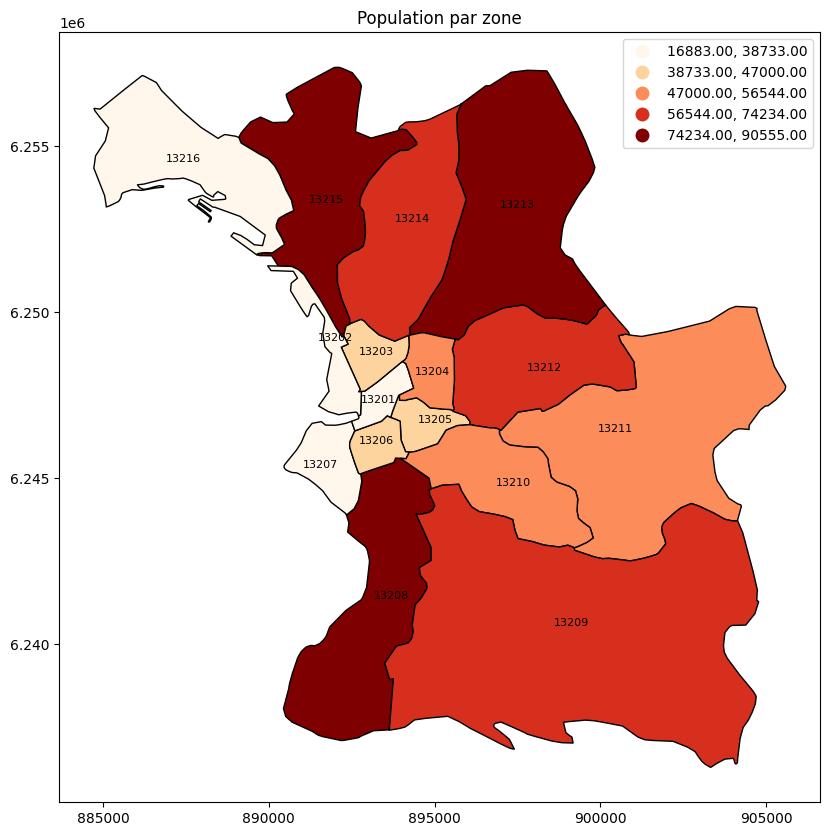

Text(0.95, 0.01, 'MOUSSA DIEYE AMU 2025 - Source : INSEE')

<Figure size 640x480 with 0 Axes>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# 1) Lire le fichier CSV d'entraînement
train_data_path = "/content/ville de marseille.shp"
df_train = gpd.read_file(train_data_path, sep=";")
print(df_train.columns)

fig, ax = plt.subplots(figsize=(10, 10))

df_train.plot(
    column='POPULATION',
    cmap='OrRd',
    scheme='quantiles',
    legend=True,
    ax=ax,
    edgecolor='black'
)
for idx, row in df_train.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, row['INSEE_COM'], fontsize=8, ha='center')
plt.title("Population par zone")
plt.show()


plt.figtext(
    0.95, 0.01,
    "MOUSSA DIEYE AMU 2025 - Source : INSEE",
    ha='right',
    fontsize=9,
    color='gray'
)





--- Entraînement du modèle Random Forest ---

Données d'entraînement chargées.


,fid,area,MNH_max,genus,species,height,numero,classe,conifere,Intensity_mean,Intensity_stdev,Nbreturns_mean,Nbreturns_stdev
0,21673,19.60,7.259552,Abies,alba,8.71,8,Conifère,1,1666.514286,829.636483,1.751020,0.815193
1,9692,48.92,9.959461,Acacia,dealbata,8.59,8,Conifère,1,1475.141455,872.332205,2.231398,0.863313
2,14694,24.28,5.003033,Acer,campestre,5.45,9,Feuillu,2,1657.971993,914.606242,1.449753,0.526431
3,14986,16.44,5.111652,Acer,monspessulanum,5.24,9,Feuillu,2,1333.233577,733.249120,1.936740,0.687665
4,15691,10.68,5.119461,Acer,pseudoplatanus,5.60,9,Feuillu,2,1815.595506,981.002511,1.614232,0.609740



Données d'entraînement nettoyées. Nombre de lignes restantes : 17516

Genres sélectionnés pour l'entraînement : ['Celtis', 'Platanus', 'Tilia', 'Pinus', 'Gleditsia']

Mapping labels : {'Celtis': np.int64(0), 'Gleditsia': np.int64(1), 'Pinus': np.int64(2), 'Platanus': np.int64(3), 'Tilia': np.int64(4)}

Entraînement du modèle Random Forest (sans pondération des classes)...
Modèle entraîné.

--- Évaluation du modèle sur l'ensemble de test ---

Rapport de Classification :
              precision    recall  f1-score   support

      Celtis       0.76      0.81      0.79      1374
   Gleditsia       0.65      0.53      0.58       217
       Pinus       0.83      0.96      0.89       620
    Platanus       0.79      0.80      0.80       831
       Tilia       0.55      0.42      0.47       684

    accuracy                           0.75      3726
   macro avg       0.72      0.71      0.71      3726
weighted avg       0.73      0.75      0.74      3726



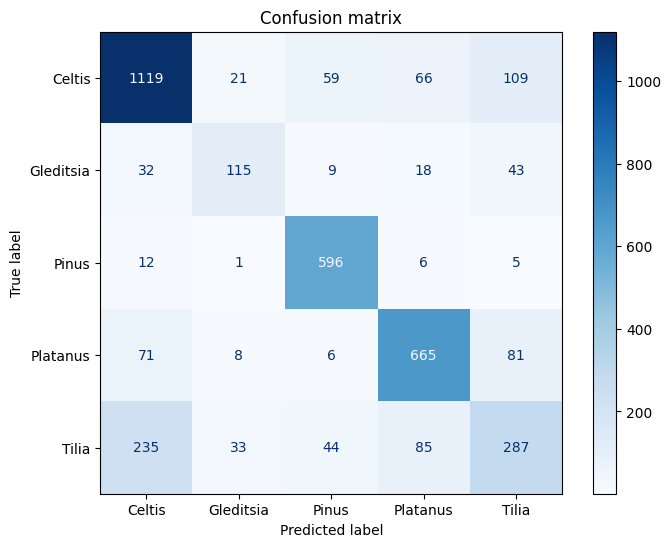


Accuracy globale : 0.747
Coefficient Kappa : 0.659

Sensibilité par classe :
  Celtis: 0.814
  Gleditsia: 0.530
  Pinus: 0.961
  Platanus: 0.800
  Tilia: 0.420

Spécificité par classe :
  Celtis: 0.851
  Gleditsia: 0.982
  Pinus: 0.962
  Platanus: 0.940
  Tilia: 0.922


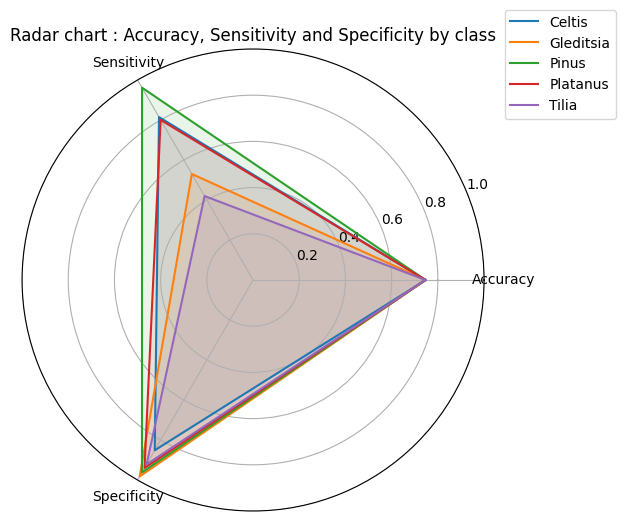


--- Application du modèle au nouveau fichier et export ---

Nouveau fichier de données chargé.


,fid,area,MNH_max,numero,classe,Intensity_mean,Intensity_stdev,NbReturns_mean,NbReturns_stdev
0,1,7.28,22.532425,8,Conifère,1114.956044,550.846599,1.967033,1.052997
1,2,2.08,2.474625,9,Feuillu,1705.923077,875.449881,1.865385,0.680182
2,3,4.04,6.331573,9,Feuillu,1477.940594,648.760140,2.019802,0.703319
3,4,3.00,2.949051,9,Feuillu,2717.320000,851.688271,1.213333,0.409661
4,5,5.88,5.298401,9,Feuillu,1502.013605,645.878055,1.387755,0.588426



Nouveau fichier traité avec les colonnes initiales conservées. Nombre de lignes : 872163


,fid,area,MNH_max,Intensity_mean,Intensity_stdev,NbReturns_mean,NbReturns_stdev,classe
0,1,7.28,22.532425,1114.956044,550.846599,1.967033,1.052997,Conifère
1,2,2.08,2.474625,1705.923077,875.449881,1.865385,0.680182,Feuillu
2,3,4.04,6.331573,1477.940594,648.760140,2.019802,0.703319,Feuillu
3,4,3.00,2.949051,2717.320000,851.688271,1.213333,0.409661,Feuillu
4,5,5.88,5.298401,1502.013605,645.878055,1.387755,0.588426,Feuillu



Colonnes renommées si nécessaire.
Colonne 'conifere' créée à partir de la colonne 'classe'.

Lignes avec valeurs manquantes dans les caractéristiques du modèle supprimées. 0 lignes supprimées.

Données préparées pour la prédiction. Dimensions : (872163, 7)


...


Prédictions de genus effectuées avec succès sur le nouveau fichier.
Exemple des premières prédictions de Genus :
['Pinus' 'Tilia' 'Celtis' 'Tilia' 'Tilia' 'Tilia' 'Celtis' 'Pinus'
 'Celtis' 'Pinus']

Colonne 'Predicted_Genus' ajoutée au DataFrame des nouvelles données traitées.


,fid,area,MNH_max,Intensity_mean,Intensity_stdev,Nbreturns_mean,Nbreturns_stdev,classe,conifere,Predicted_Genus
0,1,7.28,22.532425,1114.956044,550.846599,1.967033,1.052997,Conifère,1,Pinus
1,2,2.08,2.474625,1705.923077,875.449881,1.865385,0.680182,Feuillu,2,Tilia
2,3,4.04,6.331573,1477.940594,648.760140,2.019802,0.703319,Feuillu,2,Celtis
3,4,3.00,2.949051,2717.320000,851.688271,1.213333,0.409661,Feuillu,2,Tilia
4,5,5.88,5.298401,1502.013605,645.878055,1.387755,0.588426,Feuillu,2,Tilia



Prédictions filtrées pour inclure uniquement les genres d'intérêt (['Celtis', 'Platanus', 'Tilia', 'Pinus', 'Gleditsia']).
Nombre de lignes après filtrage : 872163


,fid,area,MNH_max,Intensity_mean,Intensity_stdev,Nbreturns_mean,Nbreturns_stdev,classe,conifere,Predicted_Genus
0,1,7.28,22.532425,1114.956044,550.846599,1.967033,1.052997,Conifère,1,Pinus
1,2,2.08,2.474625,1705.923077,875.449881,1.865385,0.680182,Feuillu,2,Tilia
2,3,4.04,6.331573,1477.940594,648.760140,2.019802,0.703319,Feuillu,2,Celtis
3,4,3.00,2.949051,2717.320000,851.688271,1.213333,0.409661,Feuillu,2,Tilia
4,5,5.88,5.298401,1502.013605,645.878055,1.387755,0.588426,Feuillu,2,Tilia


✅ CSV filtré sauvegardé : /content/predictions_new_data_filtered/predictions_genus_new_data_filtered.csv

⚠️ La colonne de géométrie n'est pas présente dans le DataFrame filtré, l'export GeoPackage est ignoré.

--- Processus terminé ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, cohen_kappa_score

# --- Partie 1: Entraînement du modèle Random Forest sur le premier fichier ---

print("--- Entraînement du modèle Random Forest ---")

# 1) Lire le fichier CSV d'entraînement
train_data_path = "/content/ville de marseille.shp"
df_train = gpd.read_file(train_data_path, sep=";")

print("\nDonnées d'entraînement chargées.")
display(df_train.head())

# 2) Nettoyer : enlever les lignes incomplètes pour les colonnes choisies
subset_cols_train = ['area', 'MNH_max', 'Intensity_mean', 'Intensity_stdev', 'Nbreturns_mean', 'Nbreturns_stdev', 'conifere', 'genus']
df_train = df_train.dropna(subset=subset_cols_train)

# Convert 'area' to numeric after dropping NaNs in relevant columns
df_train['area'] = pd.to_numeric(df_train['area'])


print(f"\nDonnées d'entraînement nettoyées. Nombre de lignes restantes : {len(df_train)}")

# 3) Filtrer les 5 genres les plus fréquents
top_genus = df_train['genus'].value_counts().nlargest(5).index
df_train = df_train[df_train['genus'].isin(top_genus)].copy() # Utiliser .copy() pour éviter SettingWithCopyWarning
print("\nGenres sélectionnés pour l'entraînement :", list(top_genus))

# 4) Encoder les labels
le = LabelEncoder()
df_train['Label'] = le.fit_transform(df_train['genus'])
print("\nMapping labels :", dict(zip(le.classes_, le.transform(le.classes_))))

# 5) Définir les variables X et y pour l'entraînement
features = ['area', 'MNH_max', 'Intensity_mean', 'Intensity_stdev', 'Nbreturns_mean', 'Nbreturns_stdev', 'conifere']
X_train, y_train = df_train[features], df_train['Label']

# Split train/test pour l'évaluation interne du modèle
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)


# 6) Modèle Random Forest sans pondération des classes (modification ici)
# clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1) # Modèle équilibré
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1) # Modèle non équilibré
print("\nEntraînement du modèle Random Forest (sans pondération des classes)...")
clf.fit(X_train_split, y_train_split)
print("Modèle entraîné.")

# 7) Évaluation du modèle
print("\n--- Évaluation du modèle sur l'ensemble de test ---")
y_pred_split = clf.predict(X_test_split)

# Rapport de classification complet
print("\nRapport de Classification :")
print(classification_report(y_test_split, y_pred_split, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test_split, y_pred_split)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix")
plt.show()

# Calcul des métriques
accuracy = accuracy_score(y_test_split, y_pred_split)
kappa = cohen_kappa_score(y_test_split, y_pred_split)
sensitivity_per_class = recall_score(y_test_split, y_pred_split, average=None)

# Spécificité par classe
specificity_per_class = []
cm_eval = confusion_matrix(y_test_split, y_pred_split)
for i in range(len(le.classes_)):
    tn = cm_eval.sum() - (cm_eval[i, :].sum() + cm_eval[:, i].sum() - cm_eval[i, i])
    fp = cm_eval[:, i].sum() - cm_eval[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_per_class.append(specificity)

print(f"\nAccuracy globale : {accuracy:.3f}")
print(f"Coefficient Kappa : {kappa:.3f}")
print("\nSensibilité par classe :")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {sensitivity_per_class[i]:.3f}")
print("\nSpécificité par classe :")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {specificity_per_class[i]:.3f}")


# Graphique radar
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # fermer le radar

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, class_name in enumerate(le.classes_):
    values = [
        accuracy,  # accuracy globale pour référence
        sensitivity_per_class[i],
        specificity_per_class[i]
    ]
    values += values[:1]  # fermer le graphique
    ax.plot(angles, values, label=class_name)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_ylim(0, 1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Radar chart : Accuracy, Sensitivity and Specificity by class")
plt.show()


# --- Partie 2: Application du modèle au nouveau fichier et export ---

print("\n--- Application du modèle au nouveau fichier et export ---")

# 1. Charger le "nouveau" fichier
new_data_path = "/content/Canopee_IGN_MNH_Cosia_Zonal_stats.gpkg.csv"
df_new_data = pd.read_csv(new_data_path)

print("\nNouveau fichier de données chargé.")
display(df_new_data.head())


# Conserver une copie avec les colonnes importantes, y compris la géométrie si elle est présente
cols_to_keep_initial_new = ['fid', 'area', 'MNH_max', 'Intensity_mean', 'Intensity_stdev', 'NbReturns_mean', 'NbReturns_stdev', 'classe']

# Ajouter les colonnes de géométrie si elles existent dans le nouveau fichier
geometry_cols = ['geometry', 'X', 'Y', 'lon', 'lat'] # Ajoutez d'autres noms si nécessaire
for col in geometry_cols:
    if col in df_new_data.columns:
        cols_to_keep_initial_new.append(col)
    elif f'geom_{col.lower()}' in df_new_data.columns: # Vérifier les variantes de noms de colonnes géométriques
         cols_to_keep_initial_new.append(f'geom_{col.lower()}')

# Filtrer le DataFrame pour ne garder que les colonnes initialement sélectionnées
df_new_data_processed = df_new_data[cols_to_keep_initial_new].copy()
print(f"\nNouveau fichier traité avec les colonnes initiales conservées. Nombre de lignes : {len(df_new_data_processed)}")
display(df_new_data_processed.head())


# 2. Préparation des données : Renommer et gérer 'conifere'
if 'NbReturns_mean' in df_new_data_processed.columns and 'Nbreturns_mean' not in df_new_data_processed.columns:
    df_new_data_processed.rename(columns={'NbReturns_mean': 'Nbreturns_mean'}, inplace=True)
if 'NbReturns_stdev' in df_new_data_processed.columns and 'Nbreturns_stdev' not in df_new_data_processed.columns:
     df_new_data_processed.rename(columns={'NbReturns_stdev': 'Nbreturns_stdev'}, inplace=True)
print("\nColonnes renommées si nécessaire.")

if 'conifere' not in df_new_data_processed.columns:
    if 'classe' in df_new_data_processed.columns:
        df_new_data_processed['conifere'] = df_new_data_processed['classe'].apply(lambda x: 1 if x == 'Conifère' else 2)
        print("Colonne 'conifere' créée à partir de la colonne 'classe'.")
    else:
        print("Attention: La colonne 'conifere' est manquante dans le nouveau fichier et la colonne 'classe' n'est pas disponible pour la dériver.")
        print("La prédiction risque d'échouer car le modèle genus attend cette colonne.")
        # Gérer l'erreur si 'conifere' ne peut pas être créée

# Define the features that the 'genus' model expects
features_genus_model_trained = ['area', 'MNH_max', 'Intensity_mean', 'Intensity_stdev', 'Nbreturns_mean', 'Nbreturns_stdev', 'conifere']

# Drop rows with missing values in these specific features *before* prediction
rows_before_dropna = len(df_new_data_processed)
df_new_data_processed.dropna(subset=features_genus_model_trained, inplace=True)
rows_after_dropna = len(df_new_data_processed)
print(f"\nLignes avec valeurs manquantes dans les caractéristiques du modèle supprimées. {rows_before_dropna - rows_after_dropna} lignes supprimées.")


# Préparer les variables explicatives (X) pour la prédiction
# S'assurer que les colonnes sont dans le bon ordre et le bon type (float32 pour éviter les erreurs de compatibilité)
try:
    X_new_data = df_new_data_processed[features_genus_model_trained].astype(np.float32)
    print(f"\nDonnées préparées pour la prédiction. Dimensions : {X_new_data.shape}")
    display(X_new_data.head())

except KeyError as e:
    print(f"\nErreur: Une colonne requise pour la prédiction est manquante dans le DataFrame traité : {e}")
    print("Veuillez vérifier les noms de colonnes dans le fichier source et les étapes de préparation.")
    X_new_data = None # Set to None to prevent prediction if columns are missing


# 3. Faire les prédictions si les données ont été préparées avec succès
if X_new_data is not None and not X_new_data.empty:
    try:
        # Faire les prédictions de label (numérique)
        y_pred_new_data_labels = clf.predict(X_new_data)

        # Convertir les labels numériques prédits en noms de genus (strings)
        y_pred_new_data_genus = le.inverse_transform(y_pred_new_data_labels)

        print("\nPrédictions de genus effectuées avec succès sur le nouveau fichier.")
        print("Exemple des premières prédictions de Genus :")
        print(y_pred_new_data_genus[:10])

        # 4. Ajouter les prédictions au nouveau DataFrame traité
        # Assurez-vous que les indices correspondent
        df_new_data_processed.loc[X_new_data.index, 'Predicted_Genus'] = y_pred_new_data_genus

        print("\nColonne 'Predicted_Genus' ajoutée au DataFrame des nouvelles données traitées.")
        display(df_new_data_processed.head())

        # 5. Filtrer les prédictions pour garder uniquement les 5 genres d'intérêt
        if 'top_genus' in globals():
            df_filtered_predictions = df_new_data_processed[df_new_data_processed['Predicted_Genus'].isin(top_genus)].copy()
            print(f"\nPrédictions filtrées pour inclure uniquement les genres d'intérêt ({list(top_genus)}).")
            print(f"Nombre de lignes après filtrage : {len(df_filtered_predictions)}")
            display(df_filtered_predictions.head())
        else:
            print("\nAttention: La variable 'top_genus' n'est pas définie. Le filtrage des prédictions ne peut pas être effectué.")
            print("Veuillez vous assurer que la partie entraînement du modèle a été exécutée.")
            df_filtered_predictions = df_new_data_processed # Utiliser les données non filtrées si le filtrage est impossible


        # 6. Sauvegarder les résultats filtrés (ou non filtrés si top_genus n'est pas défini)

        output_dir_new_data_filtered = "/content/predictions_new_data_filtered"
        os.makedirs(output_dir_new_data_filtered, exist_ok=True)

        # Sauvegarde CSV
        csv_path_new_data_filtered = os.path.join(output_dir_new_data_filtered, "predictions_genus_new_data_filtered.csv")
        df_filtered_predictions.to_csv(csv_path_new_data_filtered, index=False)
        print(f"✅ CSV filtré sauvegardé : {csv_path_new_data_filtered}")

        # Export en GeoPackage si la colonne 'geometry' est présente
        geometry_col_present = None
        for col in geometry_cols:
            if col in df_filtered_predictions.columns:
                geometry_col_present = col
                break
            elif f'geom_{col.lower()}' in df_filtered_predictions.columns:
                 geometry_col_present = f'geom_{col.lower()}'
                 break


        if geometry_col_present:
            try:
                # Convertir la colonne de géométrie du format WKT
                df_filtered_predictions[geometry_col_present] = df_filtered_predictions[geometry_col_present].apply(wkt.loads)
                # Créer un GeoDataFrame
                gdf_new_data_filtered = gpd.GeoDataFrame(df_filtered_predictions, geometry=geometry_col_present, crs="EPSG:2154") # Assurez-vous que le CRS est correct
                # Sauvegarder en GeoPackage
                gpkg_path_new_data_filtered = os.path.join(output_dir_new_data_filtered, "predictions_genus_new_data_filtered.gpkg")
                gdf_new_data_filtered.to_file(gpkg_path_new_data_filtered, driver="GPKG")
                print(f"✅ GeoPackage filtré exporté : {gpkg_path_new_data_filtered}")
            except Exception as e:
                print(f"❌ Erreur d’export GeoPackage filtré : {e}")
                print("Veuillez vérifier le format de la colonne de géométrie et le CRS.")
        else:
            print("\n⚠️ La colonne de géométrie n'est pas présente dans le DataFrame filtré, l'export GeoPackage est ignoré.")

    except Exception as e:
        print(f"\nUne erreur s'est produite lors de la prédiction ou de l'exportation: {e}")
        print("Veuillez vérifier que le modèle 'clf' et le LabelEncoder 'le' sont correctement définis (en exécutant la partie entraînement).")

else:
    print("\nPrédiction non effectuée car les données pour la prédiction sont vides ou n'ont pas pu être préparées.")


print("\n--- Processus terminé ---")

In [ ]:
df_train

,fid,area,MNH_max,genus,species,height,numero,classe,conifere,Intensity_mean,Intensity_stdev,Nbreturns_mean,Nbreturns_stdev,Label
935,923,8.72,5.016533,Celtis,australis,5.73,9,Feuillu,2,1264.807339,538.337468,1.733945,0.737491,0
936,20776,12.32,5.023102,Celtis,australis,6.50,9,Feuillu,2,1928.633117,670.346968,1.321429,0.519673,0
937,2622,13.40,5.046722,Celtis,australis,5.94,9,Feuillu,2,1333.325373,648.876985,1.644776,0.569704,0
938,17846,11.04,5.066399,Celtis,australis,5.76,9,Feuillu,2,1687.177536,875.631574,1.771739,0.627335,0
939,11890,24.44,5.069092,Celtis,occidentalis,5.65,9,Feuillu,2,1523.819967,836.549732,1.854337,0.734954,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17217,5459,272.92,21.003365,Tilia,tomentosa,17.89,9,Feuillu,2,1337.159571,760.302855,2.132413,0.974466,4
17218,16065,89.40,21.147453,Tilia,platyphyllos,21.08,8,Conifère,1,1263.161074,660.991811,2.341834,0.973666,4
17219,16062,54.60,21.698318,Tilia,platyphyllos,21.37,8,Conifère,1,1313.955311,683.328706,2.238095,0.959097,4
17220,19274,300.52,22.806976,Tilia,platyphyllos,24.54,9,Feuillu,2,1497.016256,890.656935,2.147901,1.003248,4


Ce notebook contient le code essentiel pour entraîner un modèle de détection d'objets avec Ultralytics YOLOv8 et exporter le modèle entraîné.

### Explication du code

Le code ci-dessus utilise la bibliothèque Ultralytics pour:

1.  **Charger un modèle YOLOv8 pré-entraîné** (`yolov8n.pt`). C'est un bon point de départ pour l'entraînement.
2.  **Entraîner le modèle** sur un jeu de données spécifié (`coco128.yaml`) pendant un nombre défini d'époques (`epochs=3`).
3.  **Évaluer la performance du modèle** sur l'ensemble de validation.
4.  **Effectuer une inférence** (détection d'objets) sur une image d'exemple.
5.  **Exporter le modèle entraîné** au format ONNX, un format standard pour le déploiement de modèles d'apprentissage automatique.

Ce notebook exécute un pipeline en deux parties :

**Partie 1 : Entraînement et Évaluation d'un Modèle Random Forest**

Cette section charge les données d'entraînement à partir de "/content/Greehil_especes_Lidar_canopee_zonal_statistics_filtre2.csv", nettoie les données, filtre pour les 5 genres les plus fréquents, encode les labels, divise les données pour l'entraînement et l'évaluation, entraîne un modèle Random Forest avec pondération des classes, et évalue ses performances en affichant un rapport de classification, une matrice de confusion, et des métriques clés comme l'accuracy, le Kappa, la sensibilité et la spécificité par classe.

**Partie 2 : Application du Modèle Entraîné à un Nouveau Fichier et Export des Prédictions**

Cette section charge un nouveau fichier de données ("/content/Canopee_IGN_MNH_Cosia_Zonal_stats.gpkg.csv"), prépare ces données en s'assurant que les colonnes correspondent à celles utilisées pour l'entraînement du modèle (y compris le renommage et la création de la colonne 'conifere'), utilise le modèle Random Forest entraîné pour prédire le genre pour chaque entrée du nouveau fichier, ajoute la colonne des genres prédits, filtre les résultats pour ne garder que les prédictions parmi les 5 genres d'intérêt, et enfin exporte les résultats filtrés dans un fichier CSV ("/content/predictions_new_data_filtered/predictions_genus_new_data_filtered.csv") et potentiellement un fichier GeoPackage pour une visualisation spatiale dans QGIS.


--- Importance des variables (features) ---


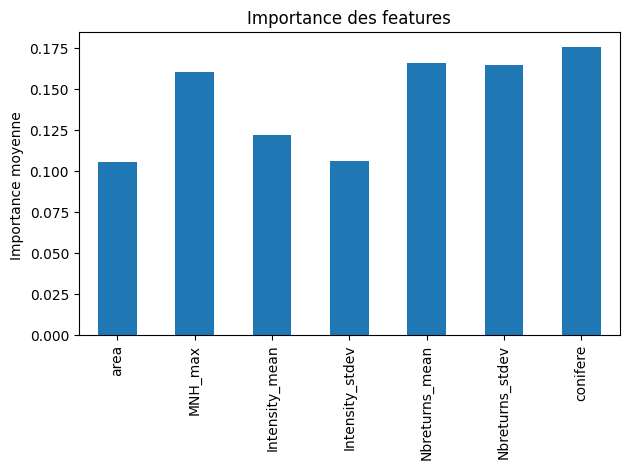

,0
conifere,0.175833
Nbreturns_mean,0.165755
Nbreturns_stdev,0.164726
MNH_max,0.160146
Intensity_mean,0.121945
Intensity_stdev,0.106080
area,0.105515


In [ ]:
# Importance des features
print("\n--- Importance des variables (features) ---")
importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=features)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Importance des features")
ax.set_ylabel("Importance moyenne ")
fig.tight_layout()
plt.show()

display(forest_importances.sort_values(ascending=False))


Generating per-species variable importance plot for the NEW data (Heatmap)...


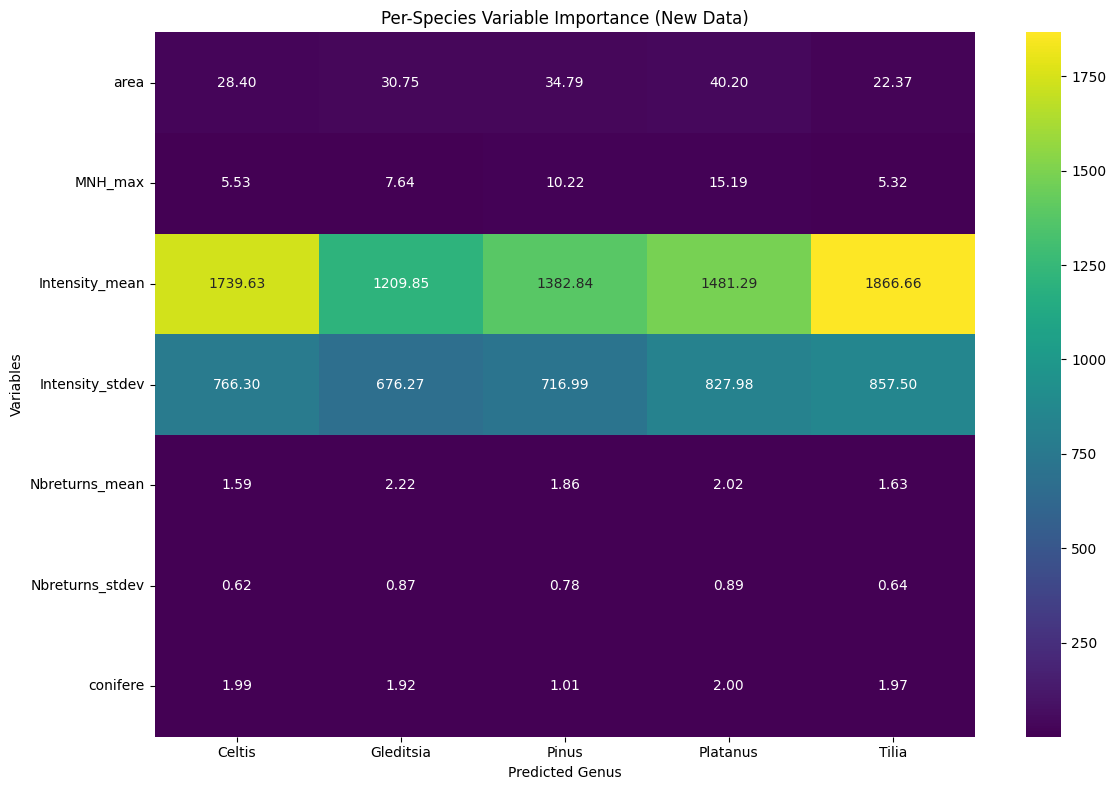

In [ ]:
# 3. Visualize the per-species variable importance for the NEW data
import seaborn as sns
print("\nGenerating per-species variable importance plot for the NEW data (Heatmap)...")

# Calculate per-species variable importance from the new data using predicted genus
# Group the new data by predicted genus and calculate the mean of the features
# Use the features that the genus model was trained on
features_for_heatmap = ['area', 'MNH_max', 'Intensity_mean', 'Intensity_stdev', 'Nbreturns_mean', 'Nbreturns_stdev', 'conifere']

if 'Predicted_Genus' in df_new_data_processed.columns:
    try:
        per_species_importance_new_data = df_new_data_processed.groupby('Predicted_Genus')[features_for_heatmap].mean()

        plt.figure(figsize=(12, 8))
        # Use the calculated per-species importance for the heatmap
        sns.heatmap(per_species_importance_new_data.T, annot=True, fmt=".2f", cmap="viridis")
        plt.title("Per-Species Variable Importance (New Data)")
        plt.xlabel("Predicted Genus")
        plt.ylabel("Variables")
        plt.tight_layout()
        plt.show()
    except KeyError as e:
        print(f"❌ Erreur lors de la génération de la heatmap : Colonne manquante dans les données traitées : {e}")
        print("Veuillez vérifier que les caractéristiques utilisées pour la heatmap existent dans 'df_new_data_processed'.")
    except Exception as e:
         print(f"❌ Une erreur s'est produite lors de la génération de la heatmap : {e}")

else:
    print("\n⚠️ La colonne 'Predicted_Genus' n'est pas présente dans le DataFrame 'df_new_data_processed'.")
    print("Veuillez vous assurer que la partie prédiction du code a été exécutée avec succès.")

In [ ]:
print("Data types of features in df_train:")
print(df_train[features].dtypes)

print("\nUnique values in the 'area' column:")
print(df_train['area'].unique())

# Check for non-numeric values in 'area'
non_numeric_area = df_train['area'][pd.to_numeric(df_train['area'], errors='coerce').isna()]
print("\nNon-numeric values found in the 'area' column:")
print(non_numeric_area)

Data types of features in df_train:
area               float64
MNH_max            float64
Intensity_mean     float64
Intensity_stdev    float64
Nbreturns_mean     float64
Nbreturns_stdev    float64
conifere           float64
dtype: object

Unique values in the 'area' column:
[  8.72  12.32  13.4  ...  54.6  300.52 200.16]

Non-numeric values found in the 'area' column:
Series([], Name: area, dtype: float64)


### Visualisation des métriques de classification

Voici un diagramme en barre qui visualise la précision, le rappel (sensibilité), le F1-score et l'accuracy globale obtenus lors de l'évaluation du modèle Random Forest sur l'ensemble de test.

*   **Précision**: Proportion d'identifications positives correctes parmi toutes les identifications positives.
*   **Rappel (Sensibilité)**: Proportion d'identifications positives correctes parmi toutes les identifications positives réelles.
*   **F1-score**: Moyenne harmonique de la précision et du rappel, utile lorsque la distribution des classes est inégale.
*   **Accuracy**: Proportion d'identifications correctes parmi toutes les identifications.

Les métriques macro avg et weighted avg sont également incluses pour fournir une vue d'ensemble des performances du modèle.

*   **Macro avg**: Moyenne non pondérée des métriques par classe.
*   **Weighted avg**: Moyenne pondérée des métriques par classe par le nombre d'échantillons réels dans chaque classe.

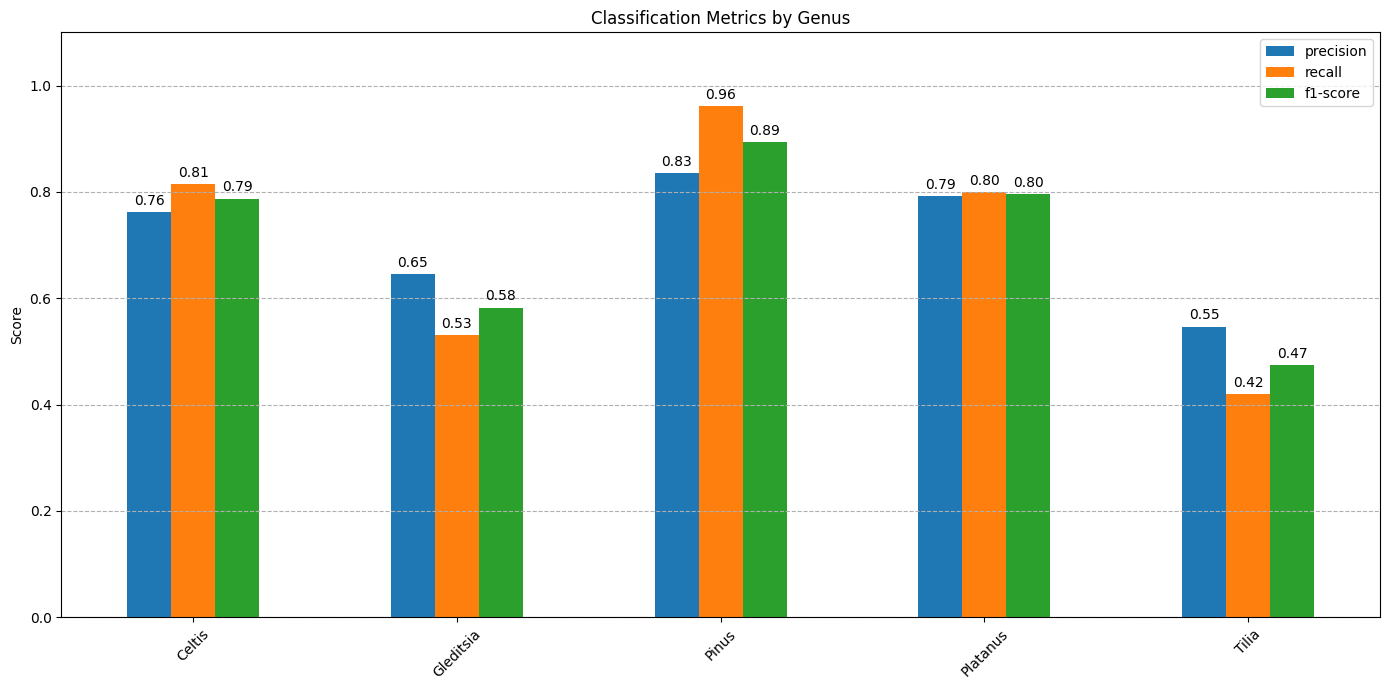


Métriques Globales:


,precision,recall,f1-score,support
accuracy,0.746645,0.746645,0.746645,0.746645
macro avg,0.716175,0.705097,0.706746,3726.000000
weighted avg,0.734343,0.746645,0.737555,3726.000000


In [ ]:
# Générer le diagramme en barre pour les métriques de classification

# Extraire le rapport de classification
report = classification_report(y_test_split, y_pred_split, target_names=le.classes_, output_dict=True)

# Créer un DataFrame à partir du rapport
df_report = pd.DataFrame(report).transpose()

# Sélectionner les métriques d'intérêt pour le graphique par classe (exclure 'support')
metrics_to_plot = ['precision', 'recall', 'f1-score']

# Supprimer les lignes macro avg et weighted avg pour le graphique par classe
df_report_classes = df_report.drop(['accuracy', 'macro avg', 'weighted avg'])

# Créer le graphique en barres groupées
ax = df_report_classes[metrics_to_plot].plot(kind='bar', figsize=(14, 7))

# Ajouter les valeurs au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

ax.set_title('Classification Metrics by Genus')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--')
ax.set_ylim(0, 1.1) # Ajuster la limite y pour laisser de la place aux labels

plt.tight_layout()
plt.show()


# Afficher les métriques globales dans un tableau séparé
print("\nMétriques Globales:")
display(df_report.loc[['accuracy', 'macro avg', 'weighted avg'], ['precision', 'recall', 'f1-score', 'support']])

### Explication du graphique "Per-Species Variable Importance" (Heatmap)

Ce graphique "Per-Species Variable Importance" visualise l'importance moyenne de chaque variable (feature) pour chaque genre (species) prédit par le modèle.

*   **Axes**: L'axe des Y représente les variables utilisées par le modèle (`area`, `MNH_max`, etc.), et l'axe des X représente les genres prédits (`Celtis`, `Gleditsia`, etc.).
*   **Couleur**: L'intensité de la couleur dans chaque cellule indique la valeur moyenne de la variable correspondante pour ce genre. Une couleur plus vive (tendant vers le jaune/blanc dans ce cas) signifie une valeur moyenne plus élevée, tandis qu'une couleur plus foncée (tendant vers le violet/bleu) indique une valeur moyenne plus faible.
*   **Annotations**: Les chiffres dans chaque cellule affichent la valeur moyenne exacte de la variable pour ce genre.

**Interprétation**:

Ce graphique permet de comprendre quelles variables sont les plus caractéristiques pour chaque genre. Par exemple :

*   Regarder la ligne `conifere` montre que les genres `Pinus` ont une valeur moyenne de cette variable plus basse (autour de 1.05), ce qui est attendu car ils sont des conifères (codé comme 1), tandis que les autres genres (Feuillus, codés comme 2) ont des valeurs plus élevées.
*   Regarder la ligne `MNH_max` peut montrer si certains genres ont tendance à avoir des hauteurs maximales plus élevées que d'autres.
*   Comparer les valeurs moyennes des variables d'intensité (`Intensity_mean`, `Intensity_stdev`) et de nombre de retours (`Nbreturns_mean`, `Nbreturns_stdev`) peut révéler des différences dans la structure du couvert ou la réponse du signal LiDAR pour chaque genre.

Ce type de visualisation est utile pour :

*   **Comprendre les caractéristiques des données**: Identifier les variables qui varient le plus entre les genres.
*   **Évaluer la pertinence des variables**: Observer si certaines variables semblent plus discriminantes pour distinguer certains genres.
*   **Obtenir des insights pour l'amélioration du modèle**: Identifier si certaines variables ne contribuent pas de manière significative à la distinction d'un genre particulier, ce qui pourrait suggérer des pistes pour la sélection de features.

Voici les formules des métriques de classification utilisées dans le rapport :

Pour une classe donnée (considérée comme la "classe positive" pour le calcul) :

*   **True Positives (TP)** : Nombre d'échantillons de cette classe correctement prédits comme appartenant à cette classe.
*   **False Positives (FP)** : Nombre d'échantillons qui n'appartiennent pas à cette classe mais qui ont été prédits comme appartenant à cette classe.
*   **False Negatives (FN)** : Nombre d'échantillons de cette classe qui n'ont pas été prédits comme appartenant à cette classe.
*   **True Negatives (TN)** : Nombre d'échantillons qui n'appartiennent pas à cette classe et qui n'ont pas été prédits comme appartenant à cette classe.

À partir de ces valeurs, on calcule les métriques par classe :

*   **Précision (Precision)** : Capacité du modèle à ne pas étiqueter comme positives des instances négatives.
    $$ \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} $$

*   **Rappel (Recall) ou Sensibilité (Sensitivity)** : Capacité du modèle à trouver toutes les instances positives.
    $$ \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} $$

*   **F1-score** : Moyenne harmonique de la précision et du rappel. Il est souvent utilisé pour évaluer les modèles sur des données déséquilibrées.
    $$ \text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

*   **Support** : Le nombre d'occurrences réelles de la classe dans l'ensemble de test.

**Métriques Globales :**

*   **Accuracy (Exactitude)** : Proportion des prédictions totales qui étaient correctes.
    $$ \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}} $$
    (Calculé globalement sur toutes les classes)

*   **Macro Average** : La moyenne non pondérée des métriques par classe. Cela donne le même poids à chaque classe, indépendamment de sa taille.
    $$ \text{Macro Precision} = \frac{1}{N} \sum_{i=1}^{N} \text{Precision}_i $$
    $$ \text{Macro Recall} = \frac{1}{N} \sum_{i=1}^{N} \text{Recall}_i $$
    $$ \text{Macro F1-score} = \frac{1}{N} \sum_{i=1}^{N} \text{F1-score}_i $$
    où $N$ est le nombre de classes.

*   **Weighted Average** : La moyenne des métriques par classe, pondérée par le support (le nombre réel d'échantillons) de chaque classe. Cela prend en compte le déséquilibre des classes.
    $$ \text{Weighted Precision} = \frac{1}{\sum_{i=1}^{N} \text{Support}_i} \sum_{i=1}^{N} \text{Precision}_i \times \text{Support}_i $$
    $$ \text{Weighted Recall} = \frac{1}{\sum_{i=1}^{N} \text{Support}_i} \sum_{i=1}^{N} \text{Recall}_i \times \text{Support}_i $$
    $$ \text{Weighted F1-score} = \frac{1}{\sum_{i=1}^{N} \text{Support}_i} \sum_{i=1}^{N} \text{F1-score}_i \times \text{Support}_i $$
    où $N$ est le nombre de classes et $\text{Support}_i$ est le support de la classe $i$.

Ces métriques vous aident à évaluer les performances de votre modèle de classification sous différents angles.

Voici les formules des métriques de classification utilisées dans le rapport, présentées sous forme d'opérations :

Pour une classe donnée (considérée comme la "classe positive" pour le calcul) :

*   **True Positives (TP)** : Nombre d'échantillons de cette classe correctement prédits comme appartenant à cette classe.
*   **False Positives (FP)** : Nombre d'échantillons qui n'appartiennent pas à cette classe mais qui ont été prédits comme appartenant à cette classe.
*   **False Negatives (FN)** : Nombre d'échantillons de cette classe qui n'ont pas été prédits comme appartenant à cette classe.
*   **True Negatives (TN)** : Nombre d'échantillons qui n'appartiennent pas à cette classe et qui n'ont pas été prédits comme appartenant à cette classe.

À partir de ces valeurs, on calcule les métriques par classe :

*   **Précision (Precision)** : Capacité du modèle à ne pas étiqueter comme positives des instances négatives.
    `Precision = TP / (TP + FP)`

*   **Rappel (Recall) ou Sensibilité (Sensitivity)** : Capacité du modèle à trouver toutes les instances positives.
    `Recall = TP / (TP + FN)`

*   **F1-score** : Moyenne harmonique de la précision et du rappel. Il est souvent utilisé pour évaluer les modèles sur des données déséquilibrées.
    `F1-score = 2 * (Precision * Recall) / (Precision + Recall)`

*   **Support** : Le nombre d'occurrences réelles de la classe dans l'ensemble de test.

**Métriques Globales :**

*   **Accuracy (Exactitude)** : Proportion des prédictions totales qui étaient correctes.
    `Accuracy = (TP + TN) / (TP + TN + FP + FN)`
    (Calculé globalement sur toutes les classes)

*   **Macro Average** : La moyenne non pondérée des métriques par classe. Cela donne le même poids à chaque classe, indépendamment de sa taille.
    `Macro Precision = Somme des Précisions par classe / Nombre de classes`
    `Macro Recall = Somme des Rappels par classe / Nombre de classes`
    `Macro F1-score = Somme des F1-scores par classe / Nombre de classes`

*   **Weighted Average** : La moyenne des métriques par classe, pondérée par le support (le nombre réel d'échantillons) de chaque classe. Cela prend en compte le déséquilibre des classes.
    `Weighted Precision = Somme (Précision par classe * Support par classe) / Somme des Supports`
    `Weighted Recall = Somme (Rappel par classe * Support par classe) / Somme des Supports`
    `Weighted F1-score = Somme (F1-score par classe * Support par classe) / Somme des Supports`

Ces métriques vous aident à évaluer les performances de votre modèle de classification sous différents angles.

Voici les formules des métriques de classification utilisées dans le rapport, présentées sous forme d'opérations :

Pour une classe donnée (considérée comme la "classe positive" pour le calcul) :

*   **True Positives (TP)** : Nombre d'échantillons de cette classe correctement prédits comme appartenant à cette classe.
*   **False Positives (FP)** : Nombre d'échantillons qui n'appartiennent pas à cette classe mais qui ont été prédits comme appartenant à cette classe.
*   **False Negatives (FN)** : Nombre d'échantillons de cette classe qui n'ont pas été prédits comme appartenant à cette classe.
*   **True Negatives (TN)** : Nombre d'échantillons qui n'appartiennent pas à cette classe et qui n'ont pas été prédits comme appartenant à cette classe.

À partir de ces valeurs, on calcule les métriques par classe :

*   **Précision (Precision)** : Capacité du modèle à ne pas étiqueter comme positives des instances négatives.
    `Precision = TP / (TP + FP)`
*   **Rappel (Recall) ou Sensibilité (Sensitivity)** : Capacité du modèle à trouver toutes les instances positives.
    `Recall = TP / (TP + FN)`
*   **F1-score** : Moyenne harmonique de la précision et du rappel. Il est souvent utilisé pour évaluer les modèles sur des données déséquilibrées.
    `F1-score = 2 * (Precision * Recall) / (Precision + Recall)`
*   **Support** : Le nombre d'occurrences réelles de la classe dans l'ensemble de test.

**Métriques Globales :**

*   **Accuracy (Exactitude)** : Proportion des prédictions totales qui étaient correctes.
    `Accuracy = (TP + TN) / (TP + TN + FP + FN)`
    (Calculé globalement sur toutes les classes)
*   **Macro Average** : La moyenne non pondérée des métriques par classe. Cela donne le même poids à chaque classe, indépendamment de sa taille.
    `Macro Precision = Somme des Précisions par classe / Nombre de classes`
    `Macro Recall = Somme des Rappels par classe / Nombre de classes`
    `Macro F1-score = Somme des F1-scores par classe / Nombre de classes`
*   **Weighted Average** : La moyenne des métriques par classe, pondérée par le support (le nombre réel d'échantillons) de chaque classe. Cela prend en compte le déséquilibre des classes.
    `Weighted Precision = Somme (Précision par classe * Support par classe) / Somme des Supports`
    `Weighted Recall = Somme (Rappel par classe * Support par classe) / Somme des Supports`
    `Weighted F1-score = Somme (F1-score par classe * Support par classe) / Somme des Supports`

Ces métriques vous aident à évaluer les performances de votre modèle de classification sous différents angles.